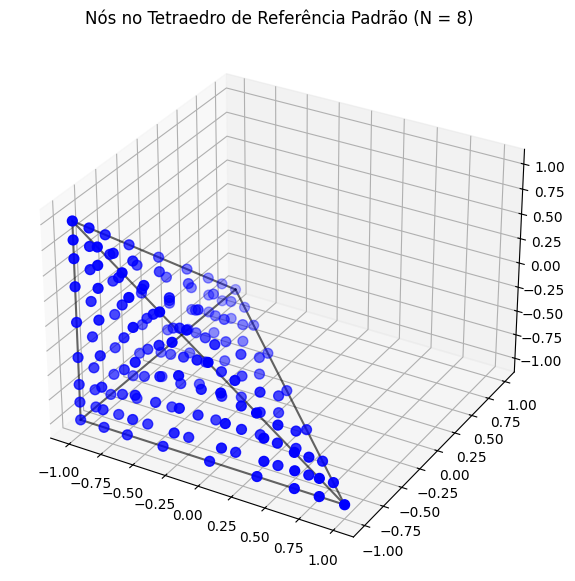

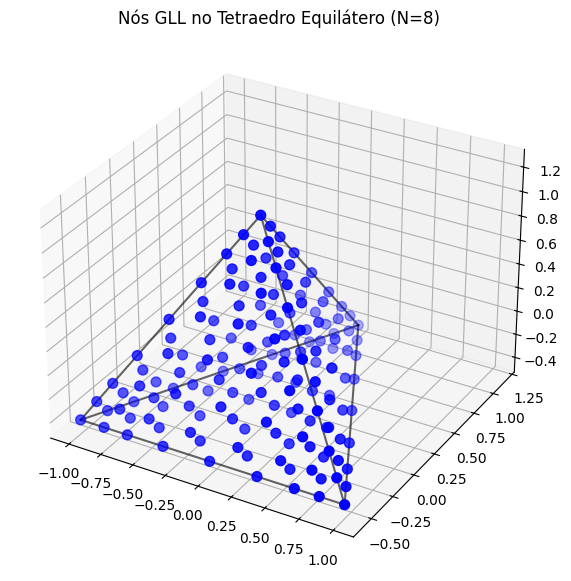

In [1]:
import matplotlib.pyplot as plt
from Nodes3D import Nodes3D, xyztorst
import numpy as np

N = 8

x, y, z = Nodes3D(N)
r, s, t = xyztorst(x, y, z)

# 1. Vértices do Tetraedro de Referência Padrão
vr1 = np.array([-1, -1, -1])
vr2 = np.array([ 1, -1, -1])
vr3 = np.array([-1,  1, -1])
vr4 = np.array([-1, -1,  1])
vertices_ref = [vr1, vr2, vr3, vr4]

# As arestas conectam os mesmos índices
arestas = [(0, 1), (1, 2), (2, 0), (0, 3), (1, 3), (2, 3)]

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# ATENÇÃO: Plote r, s, t aqui em vez de X, Y, Z
ax.scatter(r, s, t, c='blue', marker='o', s=50, label='Nós (r,s,t)')

# Plota as arestas retas do tetraedro de referência
for i, j in arestas:
    p1 = vertices_ref[i]
    p2 = vertices_ref[j]
    ax.plot(
        [p1[0], p2[0]], 
        [p1[1], p2[1]], 
        [p1[2], p2[2]], 
        color='black', linewidth=1.5, alpha=0.6
    )

ax.set_title(f'Nós no Tetraedro de Referência Padrão (N = {N})')
plt.show()

# 1. Defina os vértices (os mesmos do seu código Nodes3D)
v1 = np.array([-1, -1/np.sqrt(3), -1/np.sqrt(6)])
v2 = np.array([1, -1/np.sqrt(3), -1/np.sqrt(6)])
v3 = np.array([0.0, 2/np.sqrt(3), -1/np.sqrt(6)])
v4 = np.array([0.0, 0.0, 3/np.sqrt(6)])
vertices = [v1, v2, v3, v4]

# 2. Defina os pares de vértices que formam as 6 arestas
arestas = [
    (0, 1), (1, 2), (2, 0), # As 3 arestas da base
    (0, 3), (1, 3), (2, 3)  # As 3 arestas que sobem até o topo (v4)
]

# Configuração da figura (supondo que X, Y e Z são o retorno da sua função Nodes3D)
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Plota os nós em azul
ax.scatter(x, y, z, c='blue', marker='o', s=50, label='Nós')

# Plota as arestas do tetraedro
for i, j in arestas:
    p1 = vertices[i]
    p2 = vertices[j]
    # O comando plot precisa de uma lista de X, uma de Y e uma de Z
    ax.plot(
        [p1[0], p2[0]], 
        [p1[1], p2[1]], 
        [p1[2], p2[2]], 
        color='black', linewidth=1.5, alpha=0.6 # alpha deixa a linha levemente transparente
    )

ax.set_title(f'Nós GLL no Tetraedro Equilátero (N={N})')
plt.show()

In [2]:
from Nodes3D import Nodes3D, xyztorst
from operators3D import Vandermonde3D
import numpy as np

print("Testando o Número de Condição da Matriz de Vandermonde 3D")
print("-" * 55)
print(f"{'Ordem (N)':<12} | {'Tamanho (Np)':<15} | {'Num. Condição':<20}")
print("-" * 55)

for N in range(1, 11):
    # 1. Obtém os nós x, y otimizados (Warp & Blend)
    x, y, z = Nodes3D(N)
    
    # 2. Transforma para as coordenadas do triângulo de referência r, s, t
    r, s, t = xyztorst(x, y, z)
    
    # 3. Constrói a Matriz de Vandermonde 3D
    V = Vandermonde3D(N, r, s, t)
    
    # 4. Calcula o número de condição (razão entre maior e menor valor singular)
    cond_number = np.linalg.cond(V)
    
    # Tamanho do vetor (linhas/colunas da matriz quadrada V)
    Np = int((N + 1) * (N + 2) * (N+3) / 6)
    
    print(f"{N:<12} | {Np:<15} | {cond_number:<20.4f}")
    
print("-" * 55)

Testando o Número de Condição da Matriz de Vandermonde 3D
-------------------------------------------------------
Ordem (N)    | Tamanho (Np)    | Num. Condição       
-------------------------------------------------------
1            | 4               | 2.2361              
2            | 10              | 5.9979              
3            | 20              | 10.4645             
4            | 35              | 15.5457             
5            | 56              | 18.3130             
6            | 84              | 25.0674             
7            | 120             | 36.1729             
8            | 165             | 55.2546             
9            | 220             | 90.6429             
10           | 286             | 153.9074            
-------------------------------------------------------


In [3]:
import numpy as np
from operators3D import Dmatrices3D, Vandermonde3D
from Nodes3D import Nodes3D, xyztorst

N = 5

x, y, z = Nodes3D(N)
r, s, t = xyztorst(x,y,z)

V = Vandermonde3D(N,r,s,t)

Dr, Ds, Dt = Dmatrices3D(N,r,s,t,V)

f_val = r**2 + 2*s - 3*t**2

df_dr_exato = 2 * r
df_ds_exato = 2 * np.ones_like(s)
df_dt_exato = -6 * t

df_dr_num = Dr @ f_val
df_ds_num = Ds @ f_val
df_dt_num = Dt @ f_val

erro_r = np.max(np.abs(df_dr_num - df_dr_exato))
erro_s = np.max(np.abs(df_ds_num - df_ds_exato))
erro_t = np.max(np.abs(df_dt_num - df_dt_exato))

print("Resultados do Teste da Matriz de Diferenciação:")
print("-" * 50)
print(f"Erro máximo em r (Dr): {erro_r:.3e}")
print(f"Erro máximo em s (Ds): {erro_s:.3e}")
print(f"Erro máximo em t (Dt): {erro_t:.3e}")

Resultados do Teste da Matriz de Diferenciação:
--------------------------------------------------
Erro máximo em r (Dr): 3.109e-14
Erro máximo em s (Ds): 4.619e-14
Erro máximo em t (Dt): 3.730e-14


In [6]:
import numpy as np
from Nodes3D import Nodes3D, xyztorst
from operators3D import Lift3D, Vandermonde3D, calcular_fmask3D

N = 5
tol = 1e-7
Nfp = int((N+1)*(N+2)/2)

x, y, z = Nodes3D(N)
r, s, t = xyztorst(x,y,z)

V = Vandermonde3D(N,r,s,t)
invV = np.linalg.inv(V)

M = invV.T @ invV

Fmask = calcular_fmask3D(r,s,t,tol)

LIFT = Lift3D(N,r,s,t,Fmask,V)
# Nfp = número de nós por face

# 1. Recuperamos a matriz de integração da superfície (Emat)
Emat = M @ LIFT

# 2. Somamos todas as linhas (axis=0). 
# Isso simula a integração de um vetor constante de valor "1" no volume.
# O resultado é um vetor (1 x 4*Nfp) com os "pesos de área" de cada nó da face.
pesos_superficie = np.sum(Emat, axis=0)

# 3. Separamos os pesos e somamos por face
area_face1 = np.sum(pesos_superficie[0 * Nfp : 1 * Nfp])
area_face2 = np.sum(pesos_superficie[1 * Nfp : 2 * Nfp])
area_face3 = np.sum(pesos_superficie[2 * Nfp : 3 * Nfp])
area_face4 = np.sum(pesos_superficie[3 * Nfp : 4 * Nfp])

# 4. Imprimimos o resultado
print("--- Teste Geométrico da Matriz LIFT ---")
print("-" * 50)
print(f"Área da Face 1: {area_face1:.14f} | Esperado: 2.0")
print(f"Área da Face 2: {area_face2:.14f} | Esperado: 2.0")
print(f"Área da Face 3: {area_face3:.14f} | Esperado: 2.0")
print(f"Área da Face 4: {area_face4:.14f} | Esperado: 2.0")
print("-" * 50)

erro_maximo = np.max(np.abs(np.array([area_face1, area_face2, area_face3, area_face4]) - 2.0))
print(f"O erro máximo foi de {erro_maximo:.3e}.")

--- Teste Geométrico da Matriz LIFT ---
--------------------------------------------------
Área da Face 1: 2.00000000000002 | Esperado: 2.0
Área da Face 2: 1.99999999999997 | Esperado: 2.0
Área da Face 3: 2.00000000000000 | Esperado: 2.0
Área da Face 4: 2.00000000000000 | Esperado: 2.0
--------------------------------------------------
O erro máximo foi de 3.175e-14.
